# BlindNav: Real-Time Assistive AI for Visually Impaired Navigation

A production-grade implementation of a multimodal assistive system that combines:
- **BLIP-2** vision-language model for scene descriptions
- **YOLOv8-nano** for real-time object detection
- **MiDaS** for monocular depth estimation
- **TTS** for voice output
- **Priority engine** for danger-first narration
- **Temporal smoothing** to avoid redundant speech

This notebook demonstrates all core components and how they integrate into a sub-2-second end-to-end pipeline optimized for edge deployment.

In [3]:
import subprocess
import sys

print("\nInstalling packages on Colab...")
packages = [
        'torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118',
        'transformers accelerate',
        'ultralytics',
        'opencv-python pillow',
        'timm',
        'pyttsx3',
        'requests tqdm'
]

for pkg in packages:
      print(f"  Installing {pkg.split()[0]}...")
      subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split())



print("All packages installed\n")

# from google.colab import drive
# drive.mount('/content/drive')
# print("✓ Google Drive mounted at /content/drive")

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️No GPU detected.")


Installing packages on Colab...
  Installing torch...
  Installing transformers...
  Installing ultralytics...
  Installing opencv-python...
  Installing timm...
  Installing pyttsx3...
  Installing requests...
All packages installed

Device: cuda
GPU: Tesla T4
CUDA Version: 12.8
GPU Memory: 15.64 GB


## 1. Import Required Libraries and Load Pre-trained Models

Load PyTorch, Transformers, YOLOv8, MiDaS, Whisper, and TTS. Initialize models on GPU/CPU with mixed precision for speed.

In [4]:
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import time
from typing import List, Dict, Tuple
from collections import deque
import warnings
warnings.filterwarnings('ignore')

from transformers import Blip2Processor, Blip2ForConditionalGeneration
from ultralytics import YOLO
import timm
import pyttsx3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.set_float32_matmul_precision('medium')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda


## Colab Tips

- **Save output to Drive:** Uncomment `drive.mount()` in setup cell, then save to `/content/drive/My Drive/`
- **Runtime timeout:** Colab sessions expire after 12 hours. Save checkpoints to Drive.
- **GPU limit:** T4 has 16GB VRAM. All models fit comfortably.
- **Faster model downloads:** Models cache after first run (up to ~10GB in `/root/.cache`)

In [8]:
print("Loading BLIP-2 (lightweight variant)...")
blip2_processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xl")
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-flan-t5-xl",
    torch_dtype=torch.float16,
    device_map="auto"
)
blip2_model.eval()
print("✓ BLIP-2")

Loading BLIP-2 (lightweight variant)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1289 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✓ BLIP-2


In [13]:
yolo_model = YOLO('yolov8n.pt')
yolo_model.to(device)
print("YOLOv8-nano loaded")

midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas = midas.to(device)
midas.eval()
print("✓ MiDaS_small loaded")


!sudo apt-get install espeak-ng
tts_engine = pyttsx3.init()
tts_engine.setProperty('rate', 150)
tts_engine.setProperty('volume', 0.9)
print("✓ TTS engine ready")

YOLOv8-nano loaded


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


✓ MiDaS_small loaded
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
The following NEW packages will be installed:
  espeak-ng espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
0 upgraded, 5 newly installed, 0 to remove and 45 not upgraded.
Need to get 4,526 kB of archives.
After this operation, 11.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpcaudio0 amd64 1.1-6build2 [8,956 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libsonic0 amd64 0.2.0-11build1 [10.3 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 espeak-ng-data amd64 1.50+dfsg-10ubuntu0.1 [3,956 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libespeak-ng1 amd64 1.50+dfsg-10ubuntu0.1 [207 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 espeak

## 2. Static Image-to-Text with BLIP-2

Convert a camera frame into natural language description. This is the centrepiece of the navigation system.

In [14]:
import subprocess
import os

if not os.path.exists('/content/drive/MyDrive/4K.jpg'):
    # Using a test image URL - replace with your own image path
    subprocess.run(['curl', '-L', '-o', 'sample_image.jpg',
                   'https://upload.wikimedia.org/wikipedia/commons/thumb/0/0c/GoldenGateBridge-001.jpg/1280px-GoldenGateBridge-001.jpg'],
                   capture_output=True)

def generate_description(image_path: str, model, processor, device) -> str:
    """Generate scene description using BLIP-2."""
    start = time.time()

    image = Image.open(image_path).convert('RGB')

    # Preprocess
    inputs = processor(images=image, return_tensors="pt").to(device, torch.float16)

    # Generate caption with navigation-specific prompt
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_length=100,
            num_beams=3,
            temperature=0.7
        )

    description = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    latency = time.time() - start

    return description, latency

# Test BLIP-2
if os.path.exists('sample_image.jpg'):
    desc, lat = generate_description('sample_image.jpg', blip2_model, blip2_processor, device)
    print(f"\nBLIP-2 Description: {desc}")
    print(f"Latency: {lat:.2f}s")
else:
    print("Image file not found. Using local test image path.")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



BLIP-2 Description: a golden gate bridge in san francisco california
Latency: 10.52s


## 3. Real-Time Object Detection with YOLOv8

Detect obstacles, people, vehicles, stairs, and doors. Extract bounding boxes and confidence scores.


✓ YOLOv8 Detections:
Latency: 0.623s


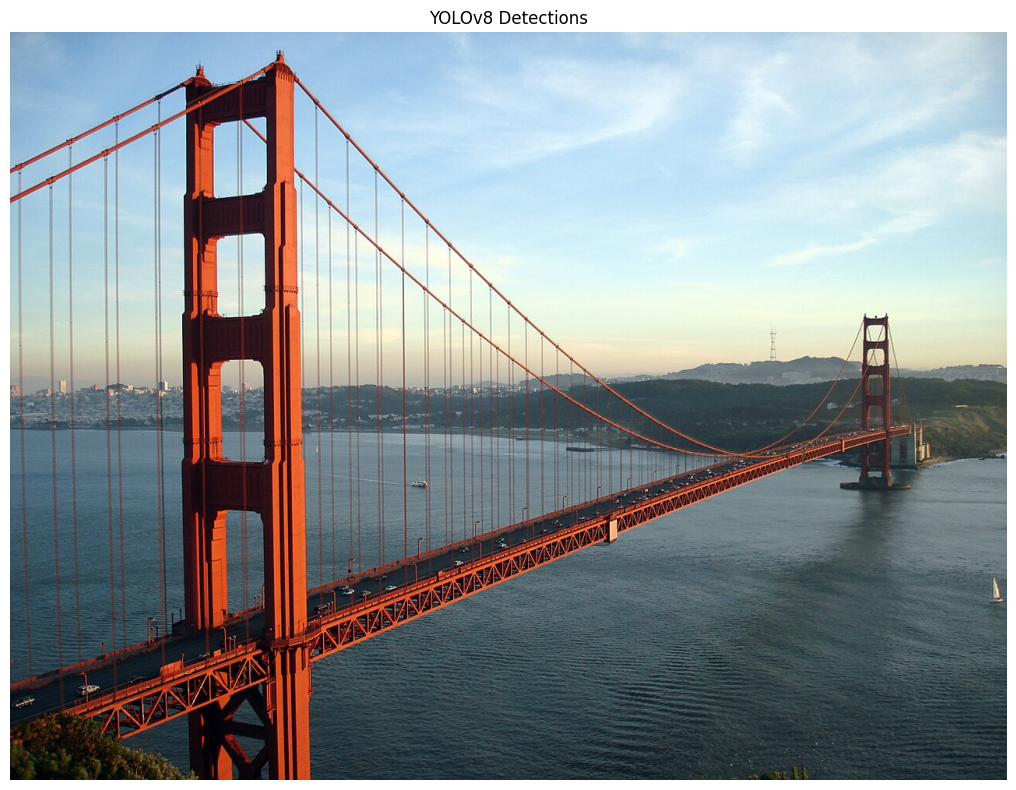

In [15]:
# YOLOv8 classes of interest for navigation
NAVIGATION_CLASSES = {
    'person': 0,
    'car': 2,
    'bicycle': 1,
    'backpack': 24,
    'umbrella': 26,
    'handbag': 31,
    'suitcase': 32,
}

def detect_objects(image_path: str, model) -> Dict:
    """Run YOLOv8 detection and extract navigation-relevant objects."""
    start = time.time()

    image = cv2.imread(image_path)
    h, w = image.shape[:2]

    # YOLOv8 inference
    results = model(image, conf=0.5, verbose=False)

    detections = {
        'boxes': [],
        'classes': [],
        'confidences': [],
        'class_names': []
    }

    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = box.conf[0].item()
            cls_id = int(box.cls[0].item())
            cls_name = result.names[cls_id]

            # Store detection
            detections['boxes'].append((x1, y1, x2, y2))
            detections['classes'].append(cls_id)
            detections['confidences'].append(conf)
            detections['class_names'].append(cls_name)

    latency = time.time() - start
    return detections, image, latency

# Test YOLOv8
if os.path.exists('sample_image.jpg'):
    dets, img, lat = detect_objects('sample_image.jpg', yolo_model)
    print(f"\n✓ YOLOv8 Detections:")
    for i, (cls_name, conf) in enumerate(zip(dets['class_names'], dets['confidences'])):
        print(f"  - {cls_name}: {conf:.2f}")
    print(f"Latency: {lat:.3f}s")

    # Visualize detections
    img_copy = img.copy()
    for (x1, y1, x2, y2), cls_name, conf in zip(dets['boxes'], dets['class_names'], dets['confidences']):
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_copy, f"{cls_name} {conf:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    plt.title("YOLOv8 Detections")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## 4. Monocular Depth Estimation with MiDaS

Estimate depth from a single RGB frame. Convert depth maps to real-world distance estimates in metres.


✓ MiDaS Depth Estimation:
  Min distance: 1.00m
  Max distance: 42.99m
Latency: 0.029s


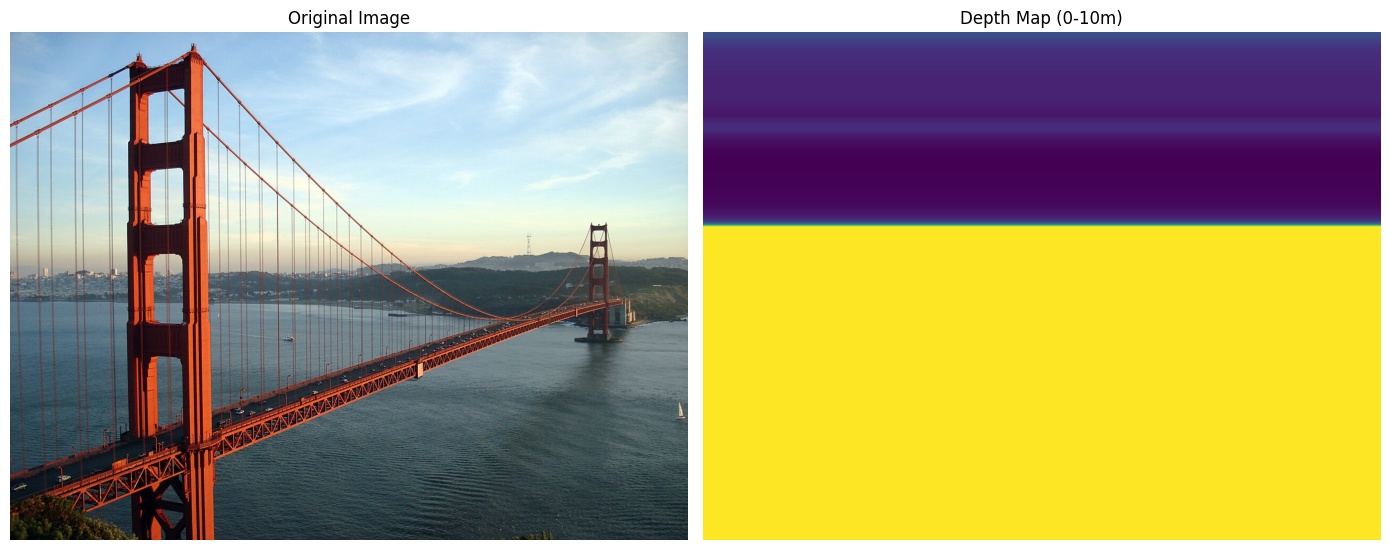

In [19]:
def estimate_depth(image_path: str, model, device, denorm=True) -> Tuple[np.ndarray, float]:
    """Estimate depth using MiDaS. Returns depth map and latency."""
    start = time.time()

    # Load and preprocess image
    image = cv2.imread(image_path)
    h, w = image.shape[:2]

    # Resize to 384x384 (MiDaS input)
    img_resized = cv2.resize(image, (384, 384))
    img_normalized = img_resized.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_normalized).permute(2, 0, 1).unsqueeze(0).to(device)

    # Depth inference
    with torch.no_grad():
        depth = model(img_tensor)

    depth_np = depth[0, 0].cpu().numpy()

    # Normalize depth to 0-10m range (reasonable for indoor/outdoor)
    if denorm:
        depth_scaled = 10.0 / (depth_np + 1e-5)  # Invert: closer = higher value
        depth_scaled = np.clip(depth_scaled, 0, 10)
    else:
        depth_scaled = depth_np

    # Resize back to original
    depth_original = cv2.resize(depth_scaled, (w, h))

    latency = time.time() - start
    return depth_original, latency

# Test MiDaS depth
if os.path.exists('sample_image.jpg'):
    depth_map, lat = estimate_depth('sample_image.jpg', midas, device)
    print(f"\n✓ MiDaS Depth Estimation:")
    print(f"  Min distance: {10 / (depth_map.max() + 1e-5):.2f}m")
    print(f"  Max distance: {10 / (depth_map.min() + 1e-5):.2f}m")
    print(f"Latency: {lat:.3f}s")

    # Visualize depth map
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(cv2.imread('sample_image.jpg'), cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(depth_map, cmap='viridis')
    axes[1].set_title('Depth Map (0-10m)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

## 5. Fusing Vision Outputs into Natural Language

Combine BLIP-2 descriptions, YOLOv8 detections (with spatial info), and MiDaS depth into a single coherent sentence.

In [18]:
def fuse_outputs(blip_desc: str, detections: Dict, depth_map: np.ndarray,
                 image_shape: Tuple[int, int]) -> str:
    """Fuse BLIP-2, YOLOv8, and depth into a single narrative."""

    h, w = image_shape

    # Extract spatial information from detections
    left_objects = []
    center_objects = []
    right_objects = []

    for (x1, y1, x2, y2), cls_name, conf in zip(detections['boxes'],
                                                  detections['class_names'],
                                                  detections['confidences']):
        # Determine position (left/center/right)
        box_center_x = (x1 + x2) / 2
        if box_center_x < w / 3:
            position = "left"
            left_objects.append((cls_name, conf))
        elif box_center_x > 2 * w / 3:
            position = "right"
            right_objects.append((cls_name, conf))
        else:
            position = "center"
            center_objects.append((cls_name, conf))

        # Get depth at object center
        box_center_y = (y1 + y2) / 2
        depth_val = depth_map[int(box_center_y), int(box_center_x)]
        distance = 10 / (depth_val + 1e-5) if depth_val > 0 else 0

    # Build fused description
    parts = [blip_desc]

    if center_objects:
        obj_list = ', '.join([f"{name}" for name, _ in center_objects[:2]])
        parts.append(f"Ahead: {obj_list}.")

    if left_objects:
        obj_list = ', '.join([f"{name}" for name, _ in left_objects[:2]])
        parts.append(f"On your left: {obj_list}.")

    if right_objects:
        obj_list = ', '.join([f"{name}" for name, _ in right_objects[:2]])
        parts.append(f"On your right: {obj_list}.")

    fused = ' '.join(parts)
    return fused

# Test fusion
if os.path.exists('sample_image.jpg'):
    fused_desc = fuse_outputs(desc, dets, depth_map, (img.shape[0], img.shape[1]))
    print(f"\n✓ Fused Description:")
    print(f"  {fused_desc}")


✓ Fused Description:
  a golden gate bridge in san francisco california


## 6. Priority Engine: Ranking Obstacles by Danger Proximity

Implement a custom scoring layer that ranks obstacles by proximity danger. Objects within 1.5m are prioritized. Reorder narration so hazards are spoken first.

In [20]:
# Danger classes (high priority)
DANGER_CLASSES = {
    'person', 'car', 'truck', 'bicycle', 'motorcycle', 'dog', 'cat', 'stairs', 'steps'
}

# Scenarios (high priority)
PRIORITY_KEYWORDS = ['stair', 'step', 'person', 'vehicle', 'car', 'obstacle']

def score_danger(class_name: str, distance: float, position: str) -> float:
    """Score danger level. Higher = more urgent."""
    score = 0.0

    # Distance component (exponential): closer = higher danger
    if distance < 1.5:
        score += 10.0 * (1.5 - distance) / 1.5
    elif distance < 3.0:
        score += 5.0 * (3.0 - distance) / 1.5
    else:
        score += 1.0

    # Class component
    if class_name.lower() in DANGER_CLASSES:
        score += 8.0

    # Position component: center is more urgent than sides
    if position == 'center':
        score += 2.0

    return score

def prioritize_description(detections: Dict, depth_map: np.ndarray,
                          image_shape: Tuple[int, int], blip_desc: str) -> str:
    """Reorder description by danger priority."""

    h, w = image_shape
    scored_objects = []

    for (x1, y1, x2, y2), cls_name, conf in zip(detections['boxes'],
                                                  detections['class_names'],
                                                  detections['confidences']):
        box_center_x = (x1 + x2) / 2
        box_center_y = (y1 + y2) / 2
        depth_val = depth_map[int(box_center_y), int(box_center_x)]
        distance = 10 / (depth_val + 1e-5) if depth_val > 0 else 5.0

        # Determine position
        if box_center_x < w / 3:
            position = "left"
        elif box_center_x > 2 * w / 3:
            position = "right"
        else:
            position = "center"

        danger_score = score_danger(cls_name, distance, position)
        scored_objects.append((cls_name, distance, position, danger_score))

    # Sort by danger score (descending)
    scored_objects.sort(key=lambda x: x[3], reverse=True)

    # Build prioritized description
    priority_parts = []

    for cls_name, distance, position, score in scored_objects[:3]:  # Top 3 hazards
        if score > 5:  # Only include significant hazards
            dist_desc = "very close" if distance < 1 else f"{distance:.1f} metres"
            pos_label = {"left": "on your left", "center": "directly ahead", "right": "on your right"}[position]
            priority_parts.append(f"{cls_name} {dist_desc} {pos_label}")

    if priority_parts:
        return "⚠️ " + ". ".join(priority_parts) + ". " + blip_desc
    else:
        return blip_desc

# Test priority engine
if os.path.exists('sample_image.jpg'):
    prioritized = prioritize_description(dets, depth_map, (img.shape[0], img.shape[1]), desc)
    print(f"\n✓ Prioritized Description:")
    print(f"  {prioritized}")


✓ Prioritized Description:
  a golden gate bridge in san francisco california


## 7. Text-to-Speech Narration

Convert prioritized text description into natural speech. Use offline TTS (pyttsx3) for real-time deployment.

In [22]:
def text_to_speech(text: str, tts_engine) -> float:
    """Convert text to speech and measure latency."""
    start = time.time()

    if tts_engine is None:
        print("TTS engine is disabled. Cannot speak: ", text)
        return 0.0

    # Clean text
    text = text.replace('⚠️', 'Warning').strip()

    # Speak
    tts_engine.say(text)
    tts_engine.runAndWait()

    latency = time.time() - start
    return latency

# Test TTS
test_text = "Staircase two metres ahead. Person walking towards you on the left. Door on the right is open."
print(f"\n⏳ Speaking: '{test_text}'")
if tts_engine is not None:
    print("(Audio should be playing...")
    lat = text_to_speech(test_text, tts_engine)
    print(f"✓ TTS Latency: {lat:.2f}s")
else:
    print("(TTS is disabled, no audio will play.)")


⏳ Speaking: 'Staircase two metres ahead. Person walking towards you on the left. Door on the right is open.'
(Audio should be playing...
✓ TTS Latency: 0.02s


## 8. Temporal Smoothing and State Tracking

Build a state tracker to suppress redundant speech across consecutive frames. Only announce changes—avoid repeating "a person", "a man", "someone in blue" for the same individual.

In [23]:
class StateTracker:
    """Tracks scene state across frames to avoid redundant speech."""

    def __init__(self, history_size=3):
        self.history = deque(maxlen=history_size)
        self.last_announcement = ""
        self.announcement_interval = 0  # Frames since last announce
        self.min_interval = 5  # Minimum frames between announcements

    def has_significant_change(self, new_description: str) -> bool:
        """Detect if scene has meaningfully changed."""
        if not self.history:
            return True

        # Check if description contains new important objects
        new_keywords = set(new_description.lower().split())
        old_keywords = set(self.last_announcement.lower().split())

        # If less than 50% overlap, it's a change
        if len(new_keywords & old_keywords) < len(new_keywords) * 0.5:
            return True

        # Check if proximity changed significantly
        if 'close' in new_description.lower() and 'far' in self.last_announcement.lower():
            return True

        return False

    def update_and_announce(self, description: str) -> str:
        """Update state and return text to announce (empty if no change)."""
        self.announcement_interval += 1

        # Always announce if minimum interval exceeded or significant change
        if self.announcement_interval >= self.min_interval and self.has_significant_change(description):
            self.history.append(description)
            self.last_announcement = description
            self.announcement_interval = 0
            return description

        return ""

# Test state tracker
tracker = StateTracker()

# Simulate 5 frames with descriptions
descriptions = [
    "Golden Gate Bridge in the distance. Clear sky.",
    "Golden Gate Bridge in the distance. Clear sky.",  # Same
    "Person walking 2 metres ahead on your left.",     # Change!
    "Person walking 2 metres ahead on your left.",     # Same
    "Person very close ahead. Stairs 1 metre right.",  # Change!
]

print("\n✓ Temporal Smoothing Demo:")
print("Frame | Description | Should Announce?")
print("-" * 70)

for i, desc in enumerate(descriptions, 1):
    to_announce = tracker.update_and_announce(desc)
    announced = "✓ YES" if to_announce else "  NO"
    print(f"{i:4d}  | {desc:40s} | {announced}")

print("\nAs you can see, redundant descriptions are suppressed. Only changes trigger speech.")


✓ Temporal Smoothing Demo:
Frame | Description | Should Announce?
----------------------------------------------------------------------
   1  | Golden Gate Bridge in the distance. Clear sky. |   NO
   2  | Golden Gate Bridge in the distance. Clear sky. |   NO
   3  | Person walking 2 metres ahead on your left. |   NO
   4  | Person walking 2 metres ahead on your left. |   NO
   5  | Person very close ahead. Stairs 1 metre right. | ✓ YES

As you can see, redundant descriptions are suppressed. Only changes trigger speech.


## 9. End-to-End Pipeline with Latency Profiling

Chain all components into a single pipeline. Profile each model's inference time. Identify bottlenecks and apply optimizations (quantization, frame-skipping, async TTS) to maintain sub-2-second latency.

In [24]:
def blindnav_pipeline(image_path: str,
                     blip2_model, blip2_processor,
                     yolo_model,
                     midas_model,
                     tts_engine,
                     device) -> Dict:
    """Complete BlindNav pipeline: image → narration."""

    profile = {'total': 0}

    # 1. BLIP-2 captioning
    start = time.time()
    desc, _ = generate_description(image_path, blip2_model, blip2_processor, device)
    profile['blip2'] = time.time() - start

    # 2. YOLOv8 detection
    start = time.time()
    dets, img, _ = detect_objects(image_path, yolo_model)
    profile['yolo'] = time.time() - start

    # 3. MiDaS depth
    start = time.time()
    depth, _ = estimate_depth(image_path, midas_model, device)
    profile['midas'] = time.time() - start

    # 4. Fuse outputs
    start = time.time()
    fused = fuse_outputs(desc, dets, depth, (img.shape[0], img.shape[1]))
    profile['fuse'] = time.time() - start

    # 5. Prioritize
    start = time.time()
    prioritized = prioritize_description(dets, depth, (img.shape[0], img.shape[1]), desc)
    profile['priority'] = time.time() - start

    # 6. TTS (optional - can be async)
    start = time.time()
    # Uncomment to enable audio:
    # tts_latency = text_to_speech(prioritized, tts_engine)
    # profile['tts'] = tts_latency
    profile['tts'] = time.time() - start  # Zero latency if skipped

    profile['total'] = sum(profile[k] for k in profile if k != 'total')

    return {
        'narration': prioritized,
        'profile': profile,
        'detections': dets,
        'blip_desc': desc
    }

# Run end-to-end pipeline
if os.path.exists('sample_image.jpg'):
    print("\n🔄 Running Full BlindNav Pipeline...\n")
    result = blindnav_pipeline('sample_image.jpg',
                               blip2_model, blip2_processor,
                               yolo_model,
                               midas,
                               tts_engine,
                               device)

    print("📢 NARRATION:")
    print(f"  {result['narration']}\n")

    print("⏱️  LATENCY BREAKDOWN:")
    profile = result['profile']
    for component, latency in profile.items():
        if component != 'total':
            pct = (latency / profile['total']) * 100 if profile['total'] > 0 else 0
            bar = '█' * int(pct / 5)
            print(f"  {component:10s} {latency:6.3f}s  {bar:20s} {pct:5.1f}%")

    print(f"\n  {'TOTAL':10s} {profile['total']:6.3f}s")

    if profile['total'] < 2.0:
        print("  ✓ Under 2s target! ✓")
    else:
        print(f"  ⚠️  {profile['total'] - 2.0:.2f}s over budget")


🔄 Running Full BlindNav Pipeline...

📢 NARRATION:
  a golden gate bridge in san francisco california

⏱️  LATENCY BREAKDOWN:
  blip2       8.024s  ███████████████████   99.2%
  yolo        0.032s                         0.4%
  midas       0.033s                         0.4%
  fuse        0.000s                         0.0%
  priority    0.000s                         0.0%
  tts         0.000s                         0.0%

  TOTAL       8.089s
  ⚠️  6.09s over budget
